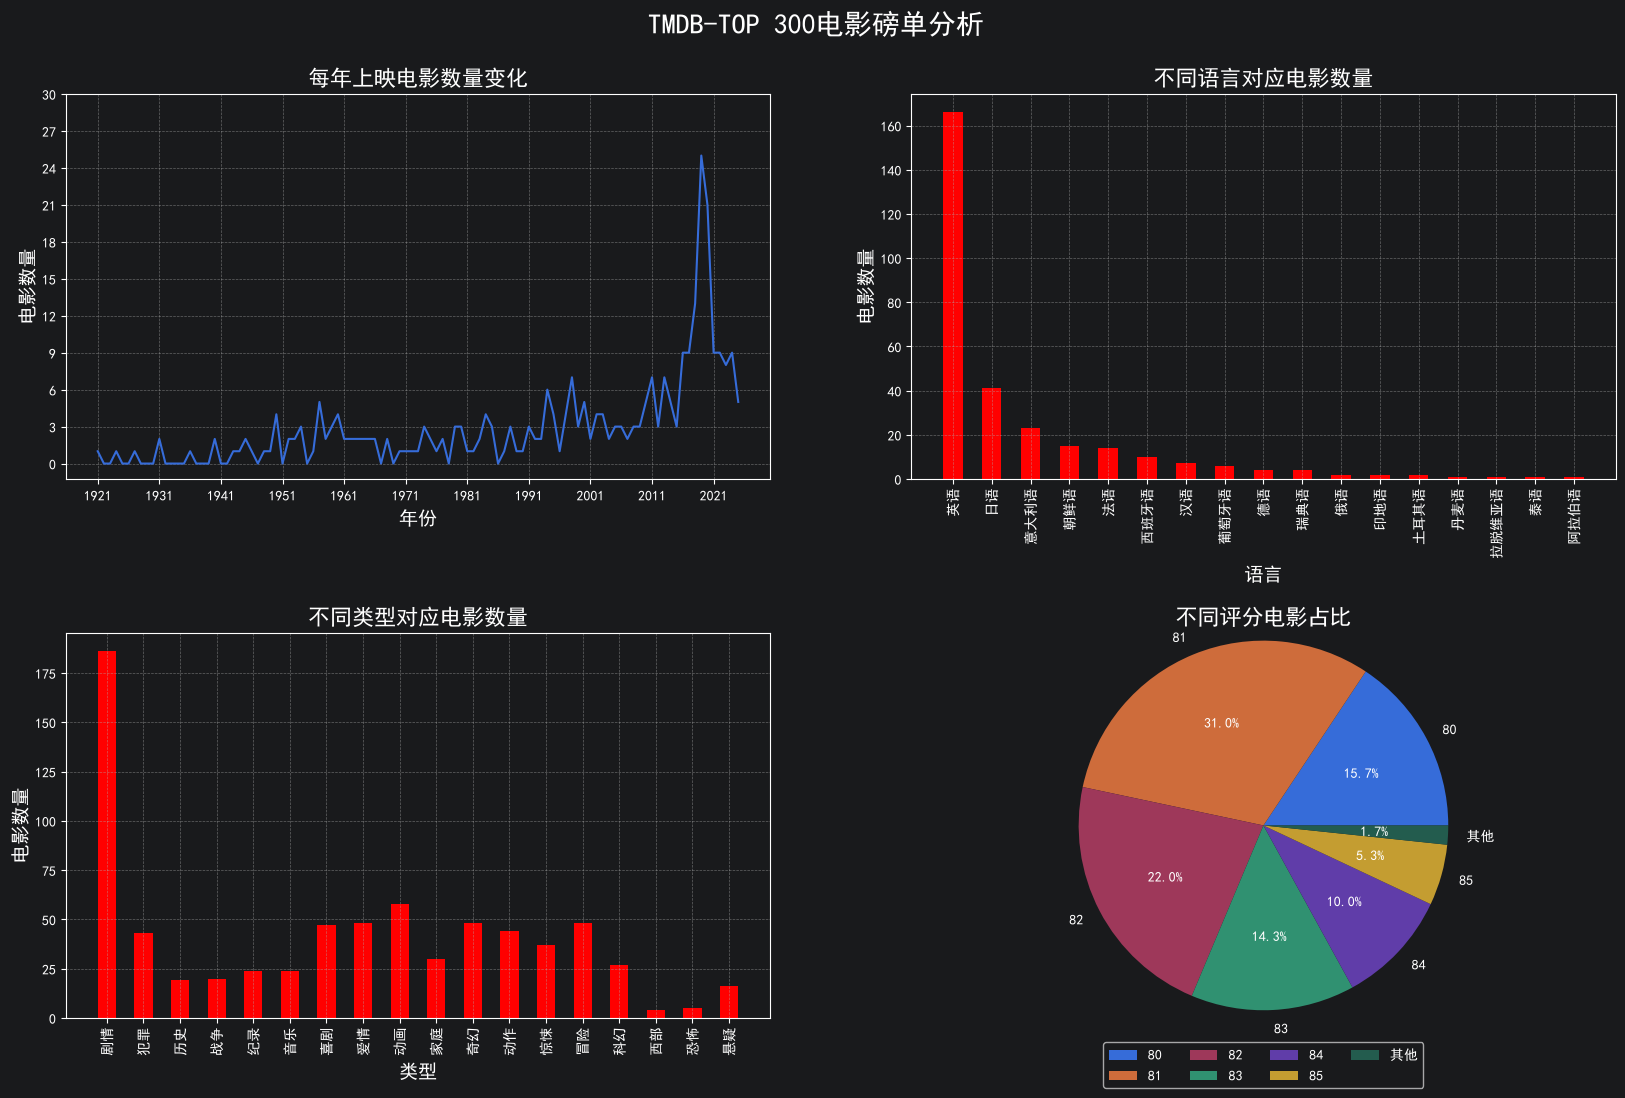

In [22]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

#展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建子图
fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(20,12),dpi=100)
fig.suptitle("TMDB-TOP 300电影磅单分析",fontsize=20,x=0.5,y=0.95)#添加画布标题,x,y控制xy位置
fig.subplots_adjust(hspace=0.4,wspace=0.2)#子图之间间距,


#获取子图
axes1:Axes=axes[0][0]
axes2:Axes=axes[0][1]
axes3:Axes=axes[1][0]
axes4:Axes=axes[1][1]


#加载数据
data=pd.read_csv("data/movies.csv",usecols=["电影名","年份","上映时间","类型","时长","评分","语言"],dtype={"年份":"Int64"})


#需求1：统计top300电影中，每一年上映电影数量的变化（折线图）
#1.1缺失值和异常值处理
#data.isnull().sum()
data["年份"]=data["年份"].fillna(data["上映时间"].str[:4])


#1.2分组操作
year_count=data.groupby("年份")["年份"].count()

#1.3组装数据
#x轴数据
min_year=year_count.index.min()
max_year=year_count.index.max()
x=[i for i in range(min_year,max_year+1)]


#y轴数据
y=[int(year_count.get(i,0)) for i in x]



#1.4绘制折线图
axes1.plot(x,y)
axes1.set_title("每年上映电影数量变化",fontsize=16)#添加标题
axes1.set_xlabel("年份",fontsize=14)#x轴标签
axes1.set_ylabel("电影数量",fontsize=14)#y轴标签

axes1.set_xticks(x[::10])#x轴刻度

y_ticks=[i for i in range(0,31,3)]
axes1.set_yticks(y_ticks)#y轴刻度

axes1.grid(linestyle="--",alpha=0.5)#网格


#需求2：统计不同语言对应电影数量
#2.1获取不同语言对应的电影数量
language_count=data.groupby("语言")["语言"].count().sort_values(ascending=False)

x_language=language_count.index.tolist()
y_language_count=language_count.values.tolist()



#2.2绘制柱状图
axes2.bar(x_language,y_language_count,color="r",width=0.5)
axes2.set_title("不同语言对应电影数量",fontsize=16)#添加标题
axes2.set_xlabel("语言",fontsize=14)#x轴标签
axes2.set_ylabel("电影数量",fontsize=14)#y轴标签
axes2.grid(linestyle="--",alpha=0.5)#网格
axes2.tick_params(axis="x",rotation=90)#x轴刻度旋转90度

#需求3：统计不同类型对应电影数量
#3.1获取不同类型对应的电影数量
type_count={}#{"犯罪":5}
for types in data["类型"].str.split(','):
    for type in types:
        if type in type_count:
            type_count[type]+=1
        else:
            type_count[type]=1


x_types=list(type_count.keys())#x轴数据
y_values=list(type_count.values())#y轴数据


#3.2绘制柱状图
axes3.bar(x_types,y_values,color="r",width=0.5)
axes3.set_title("不同类型对应电影数量",fontsize=16)#添加标题
axes3.set_xlabel("类型",fontsize=14)#x轴标签
axes3.set_ylabel("电影数量",fontsize=14)#y轴标签
axes3.grid(linestyle="--",alpha=0.5)#网格
axes3.tick_params(axis="x",rotation=90)#x轴刻度旋转90度

#需求4：统计不同评分电影占比
#4.1获取不同评分电影数量
score_count=data.groupby("评分")["评分"].count()

#合并小数据
total=score_count.sum()
large_scores=score_count[score_count>=total*0.02]#大数据（>=总数据2%），单独展示
small_scores=score_count[score_count<total*0.02]

if small_scores.shape[0]>0:
    large_scores['其他']=small_scores.sum()




scores=large_scores.index.tolist()#评分列表
scores_values=large_scores.values.tolist()#对应数量

#4.2绘制饼图
axes4.pie(scores_values,labels=scores,autopct="%1.1f%%",startangle=0,radius=1.2)
axes4.set_title("不同评分电影占比",fontsize=16)#添加标题
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.2))

#5保存画布
plt.savefig("data/TMDB-TOP 300.png")


plt.show()#显示画布
